In [1]:
import numpy as np
import matplotlib.pyplot as plt

## RK6 Method for Single Arm Pendulum

In [2]:
def RK6(t1, theta_0, v0, g, l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v0
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    for i in range(1, n):
        
        k1_v = h * F(theta[i-1])
        k1_theta = h * G(v[i-1])

        k2_v = h * F(theta[i-1] + k1_theta / 4)
        k2_theta = h * G(v[i-1] + k1_v / 4)

        k3_v = h * F(theta[i-1] + k2_theta / 4)
        k3_theta = h * G(v[i-1] + k2_v / 4)

        k4_v = h * F(theta[i-1] + k3_theta / 2)
        k4_theta = h * G(v[i-1] + k3_v / 2)

        
        k5_v = h * F(theta[i-1] - k4_theta + 2 * k3_theta)
        k5_theta = h * G(v[i-1] - k4_v + 2 * k3_v)

        k6_v = h * F(theta[i-1] + (7 * k1_theta + 6 * k2_theta + 8 * k3_theta + 3 * k4_theta) / 14)
        k6_theta = h * G(v[i-1] + (7 * k1_v + 6 * k2_v + 8 * k3_v + 3 * k4_v) / 14)



        # RK6 weights
        theta[i] = theta[i-1] + (7 * k1_theta + 32 * k3_theta + 12 * k4_theta + 32 * k5_theta + 7 * k6_theta) / 90
        v[i] = v[i-1] + (7 * k1_v + 32 * k3_v + 12 * k4_v + 32 * k5_v + 7 * k6_v) / 90
        
        if theta[i] >= 2*np.pi:
            theta[i] = theta[i]-2*np.pi

    return t,theta,v

## Variables

In [4]:
m=1
g = 9.8
l = 1.0   
t1 = 10
theta_0 = np.pi
# Adjust h to make it more accurate

## Plots

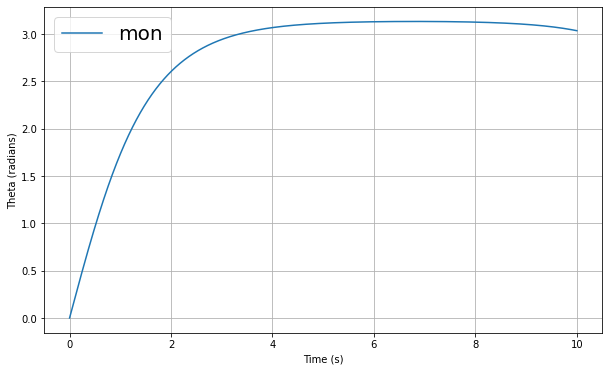

In [5]:
# Exact initial angular velocity for the pendulum to stand
angular_velocity = np.sqrt(2 * g * (1 - np.cos(theta_0)) / l)

# Convert angular velocity
exact_velocity = angular_velocity * l

plt.figure(figsize=(10, 6))
t, theta, v = RK6(t1, 0, exact_velocity, g, l, 0.0001)
plt.plot(t, theta,label='mon')

plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.legend(fontsize="20")
plt.grid(True)
plt.show()

NameError: name 'RK4' is not defined

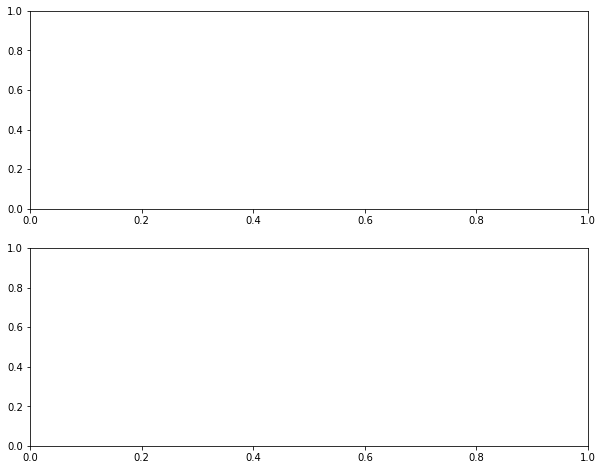

In [6]:
# Exact initial angular velocity for the pendulum to stand
angular_velocity = np.sqrt(4 * g / l)
exact_velocity = angular_velocity * l

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))


# First simulation with h=0.001
t, theta, v = RK4(t1, 0, exact_velocity, g, l, 0.00001)
ax1.plot(t, theta, label='Angle (h=1e-3)')

# Second simulation with h=1e-6
t, theta, v = RK6(t1, 0, exact_velocity, g, l, 0.00001)
ax1.plot(t, theta, label='Angle (h=1e-6)')

#energy_errors = np.zeros(len(t))
for i in range(len(t)):
    kinetic_energy = 0.5 * m * (v[i] ** 2)
    potential_energy = m * g * l * (1 - np.cos(theta[i]))
    total_energy = kinetic_energy + potential_energy
    energy_errors[i] = np.abs(total_energy - expected_total_energy)
ax2.plot(t, energy_errors, label='Energy Error (h=1e-6)')

# Setting labels and grid for the first subplot
ax1.set_xlabel('Time (s)',fontsize=20)
ax1.set_ylabel('Theta (radians)',fontsize=20)
ax1.grid(True)
ax1.legend()

# Setting labels and grid for the second subplot
ax2.set_xlabel('Time (s)',fontsize=20)
ax2.set_ylabel('Energy Error (Joules)',fontsize=20)
ax2.grid(True)
ax2.legend(fontsize="20")
plt.tight_layout()
plt.savefig('vertical_pendulum_theta.png', dpi=300)

# Display the plots
plt.tight_layout()
plt.show()


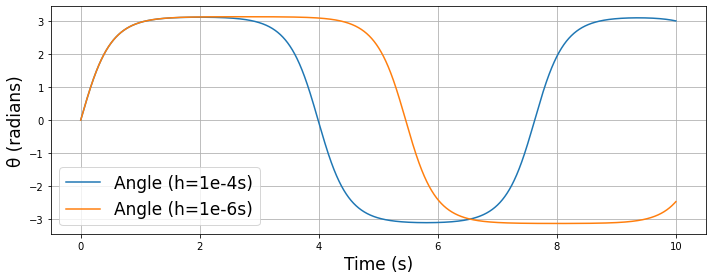

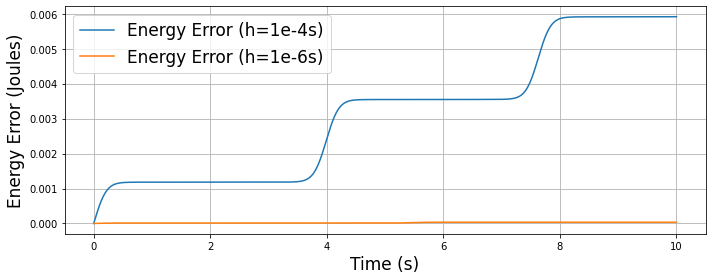

In [6]:
# Exact initial angular velocity for the pendulum to stand
angular_velocity = np.sqrt(4 * g / l)
exact_velocity = angular_velocity * l

# Simulation and plotting for both step sizes for theta
plt.figure(figsize=(10, 4))

# First simulation with h=0.001
t, theta, v = RK6(t1, 0, exact_velocity, g, l, 0.0001)
plt.plot(t, theta, label='Angle (h=1e-4s)')

# Second simulation with h=1e-6
t, theta, v = RK6(t1, 0, exact_velocity, g, l, 0.000001)
plt.plot(t, theta, label='Angle (h=1e-6s)')

plt.xlabel('Time (s)',fontsize=17)
plt.ylabel('θ (radians)',fontsize=17)
plt.grid(True)
plt.legend(fontsize="17")
plt.tight_layout()
plt.savefig('theta_plot.png', dpi=300)  # Save the theta plot

# Simulation and plotting for both step sizes for energy error
plt.figure(figsize=(10, 4))

expected_total_energy = m * g * 2 * l  # h = 2l

# Re-run simulations to calculate energy errors for both step sizes
# For h=0.001
t, theta, v = RK6(t1, 0, exact_velocity, g, l, 0.0001)
energy_errors = np.zeros(len(t))
for i in range(len(t)):
    kinetic_energy = 0.5 * m * (v[i] ** 2)
    potential_energy = m * g * l * (1 - np.cos(theta[i]))
    total_energy = kinetic_energy + potential_energy
    energy_errors[i] = np.abs(total_energy - expected_total_energy)
plt.plot(t, energy_errors, label='Energy Error (h=1e-4s)')

# For h=1e-6
t, theta, v = RK6(t1, 0, exact_velocity, g, l, 0.000001)
energy_errors = np.zeros(len(t))
for i in range(len(t)):
    kinetic_energy = 0.5 * m * (v[i] ** 2)
    potential_energy = m * g * l * (1 - np.cos(theta[i]))
    total_energy = kinetic_energy + potential_energy
    energy_errors[i] = np.abs(total_energy - expected_total_energy)
plt.plot(t, energy_errors, label='Energy Error (h=1e-6s)')

plt.xlabel('Time (s)',fontsize=17)
plt.ylabel('Energy Error (Joules)',fontsize=17)
plt.grid(True)
plt.legend(fontsize="17")
plt.tight_layout()
plt.savefig('energy_error_plot.png', dpi=300)  # Save the energy error plot


In [12]:
g=9.81

l = 1

angular_velocity = np.sqrt(4 * g / l)
print(angular_velocity)

6.26418390534633


In [15]:
1139/60

#if 1e-5 =1139/60
(5e-6*1139)/1e-5

569.5

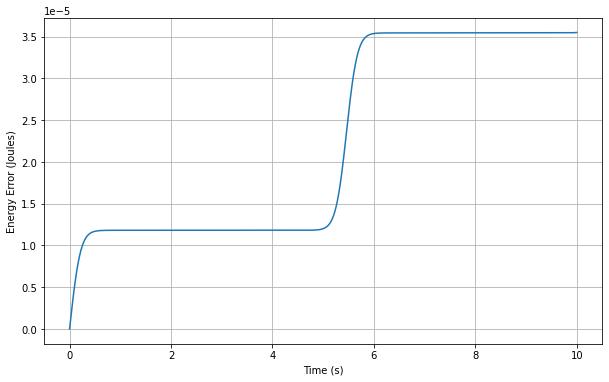

In [ ]:


energy_errors = np.zeros(len(t))
for i in range(len(t)):
    kinetic_energy = 0.5 * m * (v[i] ** 2)
    potential_energy = m * g * l * (1 - np.cos(theta[i]))
    total_energy = kinetic_energy + potential_energy

    # Error
    energy_errors[i] = np.abs(total_energy - expected_total_energy)

plt.figure(figsize=(10, 6))
plt.plot(t, energy_errors)
plt.xlabel('Time (s)')
plt.ylabel('Energy Error (Joules)')
plt.grid(True)
plt.show()

## RK4 Method for Vertical Pendulum

In [1]:
#Define the function

def RK4(t1, theta_0, v0, g, l, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = np.zeros(n) 
    #same for velocities
    v = np.zeros(n)
    
    #Set the initial value of x and v
    theta[0] = theta_0
    v[0] = v0
    
    #define F(theta) for coupled equation 1
    def F(theta):
        
        return -g/l * np.sin(theta)
    
    #Define G(v) for coupled equation 2
    def G(v):
        
        return v
    
    
    #Loop over the time values and calculate the derivatives
    for i in range(1,n): 
        
        # Calculate the Runge - Kutta intermediate values
        f1 = h * F(theta[i-1])
        g1 = h * G(v[i-1])
        
        f2 = h * F(theta[i-1]+f1/2)
        g2 = h * G(v[i-1]+g1/2)
        
        f3 = h * F(theta[i-1]+f2/2)
        g3 = h * G(v[i-1]+g2/2)
        
        f4 = h * F(theta[i-1]+f3)
        g4 = h * G(v[i-1]+g3)
        
        #g1 = h * G(v[i-1])
        #g2 = h * G(v[i-1]+g1/2)
        #g3 = h * G(v[i-1]+g2/2)
        #g4 = h * G(v[i-1]+g3)
        
        theta[i] = theta[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
        v[i] = v[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
        #if theta[i] >= 2*np.pi:
            #theta[i] = theta[i]-2*np.pi

    return(t,theta,v) 

## Plots

In [ ]:
# Exact initial angular velocity for the pendulum to stand
angular_velocity = np.sqrt(4 * g / l)

# Convert angular velocity
exact_velocity = angular_velocity * l

t, theta, v = RK4(t1, 0, exact_velocity, g, l, h)

plt.figure(figsize=(10, 6))
plt.plot(t, theta)

t, theta, v = 
plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.title('Standing Pendulum RK4 Method')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, v)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.grid(True)
plt.show()

### Error evaluation using Energy

In [ ]:
expected_total_energy = m * g * 2 * l  # h = 2l

energy_errors = np.zeros(len(t))
for i in range(len(t)):
    kinetic_energy = 0.5 * m * (v[i] ** 2)
    potential_energy = m * g * l * (1 - np.cos(theta[i]))
    total_energy = kinetic_energy + potential_energy

    # Error
    energy_errors[i] = np.abs(total_energy - expected_total_energy)

plt.figure(figsize=(10, 6))
plt.plot(t, energy_errors)
plt.xlabel('Time (s)')
plt.ylabel('Energy Error (Joules)')
plt.grid(True)
plt.show()

## Visualisation

In [ ]:
from PIL import Image
import time, os

In [ ]:
t1 = 10

theta1_0 = 0


v1_0 = 10
v2_0 = 0

h = 0.005

l1 = 0.30

t, theta1, exact_velocity = RK6(t1, 0, 2.0, 1,l, 0.0005)

x1 = l1*np.sin(theta1)
y1 = -l1*np.cos(theta1)

frames = []
for i in range(len(x1)):
    if i%50 == 0:
        fig=plt.figure()
        plt.plot((0, x1[i]), (0, y1[i]))
        plt.xlim(-1, 1)
        plt.ylim(-0.6, 0.6)
    
        canvas = plt.get_current_fig_manager().canvas
        canvas.draw()
        im = Image.frombytes('RGB', canvas.get_width_height(), canvas.tostring_rgb())
        frames.append(im)
            
    plt.close(fig)
    #plt.show(fig)

frames[0].save("vertical_pendulum_g1.gif", format='GIF', append_images=frames[1:], save_all=True, duration=100, loop=0)

IndexError: list index out of range